# Notebook 2: Exploring Quantum Machine Learning Architectures

## Classifying Handwritten Digits with Amplitude Encoding

**CQTS Summer Training Program 2026 | High School Track**

In this lesson, we will classify handwritten digits:

- 0
- 1
- 2
- 3

This notebook builds on the Iris lesson and introduces a larger QML experiment.

We will compare:

- **4, 5, and 6 qubits**
- **1, 2, and 3 quantum layers**
- `BasicEntanglerLayers`
- `StronglyEntanglingLayers`

We will also draw the circuits, plot loss and accuracy, and print a full classification report.


## Learning goals

By the end of this notebook, you will be able to:

- Work with small handwritten images
- Explain amplitude encoding
- Explain why \(n\) qubits can represent a normalized vector with \(2^n\) amplitudes
- Build circuits with PennyLane templates
- Compare different qubit counts
- Compare different circuit depths
- Compare two layer templates
- Use validation data to choose a model
- Read loss, accuracy, a confusion matrix, and a classification report

## 1. Install the libraries

The next cell installs a package only when it is missing.

In [1]:
import importlib.util
import subprocess
import sys

packages = {
    "pennylane": "pennylane",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
}

for module_name, package_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_name]
        )

print("The required libraries are ready.")

The required libraries are ready.


## 2. Import the libraries

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
)

SEED = 11
np.random.seed(SEED)

print("PennyLane version:", qml.__version__)

PennyLane version: 0.42.1


## 3. Load the Digits dataset

Each example is an $8 \times 8$ grayscale image.

An $8 \times 8$ image contains: $8 \times 8 = 64$ pixel values.

To keep the lesson simple, we will use four classes: digits 0, 1, 2, and 3.

In [3]:
digits = load_digits(n_class=4)

X = digits.data.astype(float)
y = digits.target
images = digits.images

print("Number of images:", len(X))
print("Pixels per image:", X.shape[1])
print("Classes:", np.unique(y))

Number of images: 720
Pixels per image: 64
Classes: [0 1 2 3]


## 4. View some handwritten digits

The number above each image is the correct class.

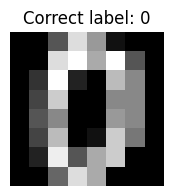

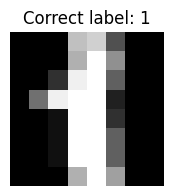

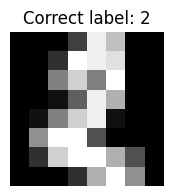

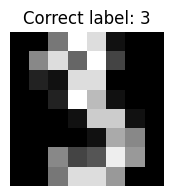

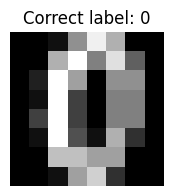

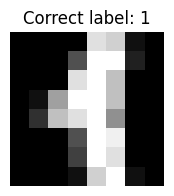

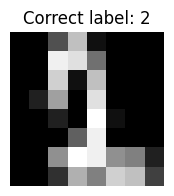

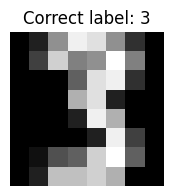

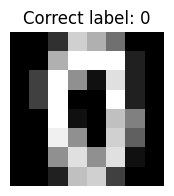

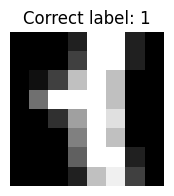

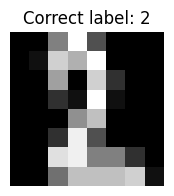

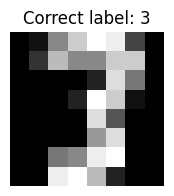

In [4]:
for index in range(12):
    plt.figure(figsize=(2, 2))
    plt.imshow(images[index], cmap="gray")
    plt.title(f"Correct label: {y[index]}")
    plt.axis("off")
    plt.show()

## 5. Create training, validation, and test sets

We use three groups:

- **Training set:** teaches the classifier
- **Validation set:** helps us choose qubits, layers, and a template
- **Test set:** checks the selected model at the end

The test set is not used to select the circuit.

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=SEED,
    stratify=y_train_full,
)

print("Training images:", len(X_train))
print("Validation images:", len(X_validation))
print("Test images:", len(X_test))

Training images: 432
Validation images: 144
Test images: 144


## 6. Amplitude encoding

The Iris notebook uses rotation angles.

This notebook uses a different method called **amplitude encoding**.

The amplitudes must satisfy:
$\sum_{i=0}^{2^n-1}|a_i|^2 = 1.$

PennyLane normalizes the input vector for us.

### Qubit count and input size

| Qubits | State amplitudes | Input values used |
|---:|---:|---:|
| 4 | \(2^4=16\) | 16 compressed image features |
| 5 | \(2^5=32\) | 32 compressed image features |
| 6 | \(2^6=64\) | all 64 image dimensions |

For 4 and 5 qubits, PCA compresses the 64 pixels before amplitude encoding.

## 7. Prepare a different input size for each qubit count

The scaler is fitted only on the training set.

PCA is also fitted only on the training set.

In [6]:
prepared_data = {}

for number_of_qubits in [4, 5, 6]:
    number_of_amplitudes = 2 ** number_of_qubits

    pixel_scaler = StandardScaler()
    scaled_train = pixel_scaler.fit_transform(X_train)
    scaled_validation = pixel_scaler.transform(X_validation)
    scaled_test = pixel_scaler.transform(X_test)

    pca = PCA(
        n_components=number_of_amplitudes,
        random_state=SEED,
    )

    amplitude_train = pca.fit_transform(scaled_train)
    amplitude_validation = pca.transform(scaled_validation)
    amplitude_test = pca.transform(scaled_test)

    prepared_data[number_of_qubits] = {
        "train": amplitude_train,
        "validation": amplitude_validation,
        "test": amplitude_test,
        "pixel_scaler": pixel_scaler,
        "pca": pca,
        "variance": pca.explained_variance_ratio_.sum(),
    }

preparation_table = pd.DataFrame({
    "Qubits": [4, 5, 6],
    "Amplitude vector length": [16, 32, 64],
    "Retained information": [
        prepared_data[q]["variance"]
        for q in [4, 5, 6]
    ],
})

preparation_table["Retained information"] = (
    preparation_table["Retained information"] * 100
)

preparation_table.round(2)

,Qubits,Amplitude vector length,Retained information
0,4,16,82.67
1,5,32,95.50
2,6,64,100.00


## 8. PennyLane layer templates

A template is a ready-made circuit pattern.

### `BasicEntanglerLayers`

Each layer has:

1. One trainable rotation on every qubit
2. A ring of CNOT gates

Its parameter count is:
$L \times n,$
where \(L\) is the number of layers and \(n\) is the number of qubits.

### `StronglyEntanglingLayers`

Each layer has:

1. Three rotation angles on every qubit
2. Entangling gates between qubits

Its parameter count is:
$3Ln.$

For this classroom experiment, the template weights are fixed random values. This keeps the architecture comparison fast and repeatable. The classical output layer is trained.

## 9. Build a circuit factory

The function below can create many circuits by changing:

- The number of qubits
- The number of layers
- The template name

Every circuit returns three measurements per qubit:

- Pauli-Z
- Pauli-X
- Pauli-Y

In [7]:
def build_quantum_feature_circuit(
    number_of_qubits,
    number_of_layers,
    template_name,
):
    device = qml.device(
        "default.qubit",
        wires=number_of_qubits,
    )

    template_code = 0 if template_name == "Basic" else 1
    weight_seed = (
        SEED
        + 100 * number_of_qubits
        + 10 * number_of_layers
        + template_code
    )
    random_generator = np.random.default_rng(weight_seed)

    if template_name == "Basic":
        weights = random_generator.normal(
            loc=0.0,
            scale=0.35,
            size=(number_of_layers, number_of_qubits),
        )
    elif template_name == "Strong":
        weights = random_generator.normal(
            loc=0.0,
            scale=0.35,
            size=(number_of_layers, number_of_qubits, 3),
        )
    else:
        raise ValueError(
            "template_name must be 'Basic' or 'Strong'."
        )

    @qml.qnode(device)
    def circuit(amplitude_vector):
        qml.AmplitudeEmbedding(
            amplitude_vector,
            wires=range(number_of_qubits),
            normalize=True,
            pad_with=0.0,
        )

        if template_name == "Basic":
            qml.BasicEntanglerLayers(
                weights,
                wires=range(number_of_qubits),
            )
        else:
            qml.StronglyEntanglingLayers(
                weights,
                wires=range(number_of_qubits),
            )

        z_values = [
            qml.expval(qml.PauliZ(wire))
            for wire in range(number_of_qubits)
        ]

        x_values = [
            qml.expval(qml.PauliX(wire))
            for wire in range(number_of_qubits)
        ]

        y_values = [
            qml.expval(qml.PauliY(wire))
            for wire in range(number_of_qubits)
        ]

        return z_values + x_values + y_values

    return circuit, weights


def create_quantum_features(circuit, amplitude_data):
    # PennyLane evaluates all rows as one batch.
    circuit_output = circuit(amplitude_data)

    # The circuit returns measurements x samples.
    # Transpose it to samples x measurements.
    return np.asarray(circuit_output, dtype=float).T

## 10. Draw the Basic template circuit

This example uses four qubits and two layers.

In [8]:
basic_circuit, basic_weights = build_quantum_feature_circuit(
    number_of_qubits=4,
    number_of_layers=2,
    template_name="Basic",
)

example_amplitudes = prepared_data[4]["train"][0]

print(
    qml.draw(
        basic_circuit,
        level="device",
    )(example_amplitudes)
)

0: ─╭|Ψ⟩──RX(0.21)──╭●───────╭X──RX(-0.34)─╭●───────╭X─┤  <Z>  <X>  <Y>
1: ─├|Ψ⟩──RX(0.80)──╰X─╭●────│───RX(-0.12)─╰X─╭●────│──┤  <Z>  <X>  <Y>
2: ─├|Ψ⟩──RX(0.15)─────╰X─╭●─│───RX(-0.18)────╰X─╭●─│──┤  <Z>  <X>  <Y>
3: ─╰|Ψ⟩──RX(-0.27)───────╰X─╰●──RX(0.23)────────╰X─╰●─┤  <Z>  <X>  <Y>


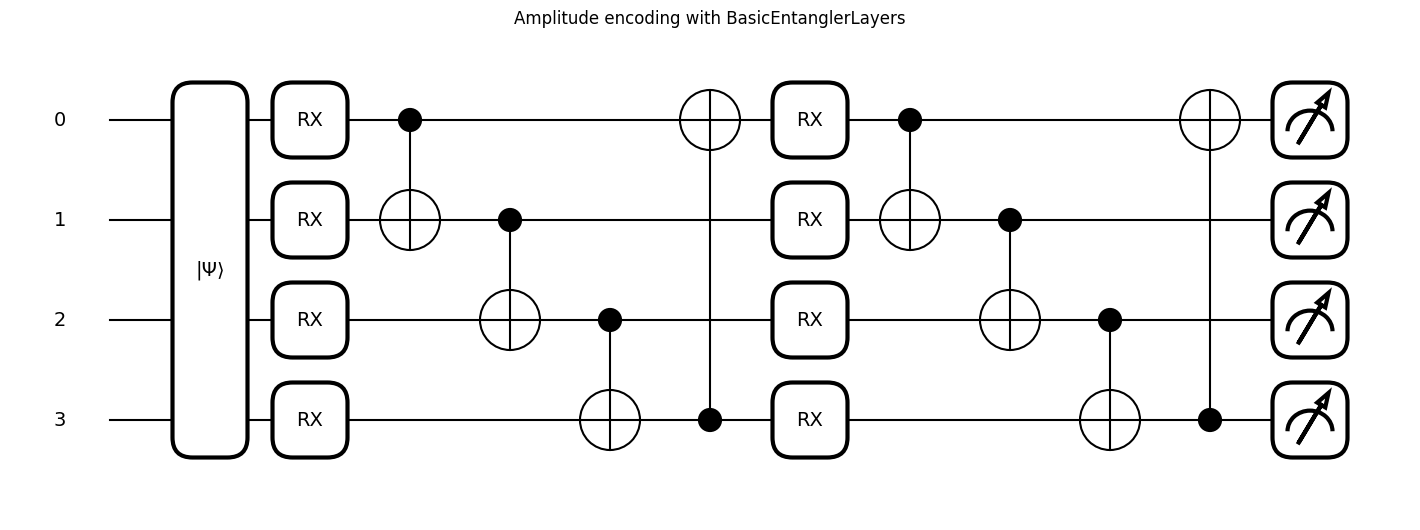

In [9]:
figure, axis = qml.draw_mpl(
    basic_circuit,
    level="device",
)(example_amplitudes)

figure.suptitle(
    "Amplitude encoding with BasicEntanglerLayers",
    y=1.02,
)
plt.show()

## 11. Draw the Strong template circuit

This example also uses four qubits and two layers.

Compare the number of rotation gates with the Basic circuit.

In [10]:
strong_circuit, strong_weights = build_quantum_feature_circuit(
    number_of_qubits=4,
    number_of_layers=2,
    template_name="Strong",
)

print(
    qml.draw(
        strong_circuit,
        level="device",
    )(example_amplitudes)
)

0: ─╭|Ψ⟩──Rot(0.25,-0.45,-0.47)─╭●───────╭X──Rot(0.74,-0.33,-0.28)─╭●────╭X────┤  <Z>  <X>  <Y>
1: ─├|Ψ⟩──Rot(-0.02,0.03,-0.20)─╰X─╭●────│───Rot(0.13,0.10,0.27)───│──╭●─│──╭X─┤  <Z>  <X>  <Y>
2: ─├|Ψ⟩──Rot(-0.39,0.08,-0.17)────╰X─╭●─│───Rot(0.25,-0.62,0.07)──╰X─│──╰●─│──┤  <Z>  <X>  <Y>
3: ─╰|Ψ⟩──Rot(0.63,-0.19,-0.70)───────╰X─╰●──Rot(0.06,0.14,0.01)──────╰X────╰●─┤  <Z>  <X>  <Y>


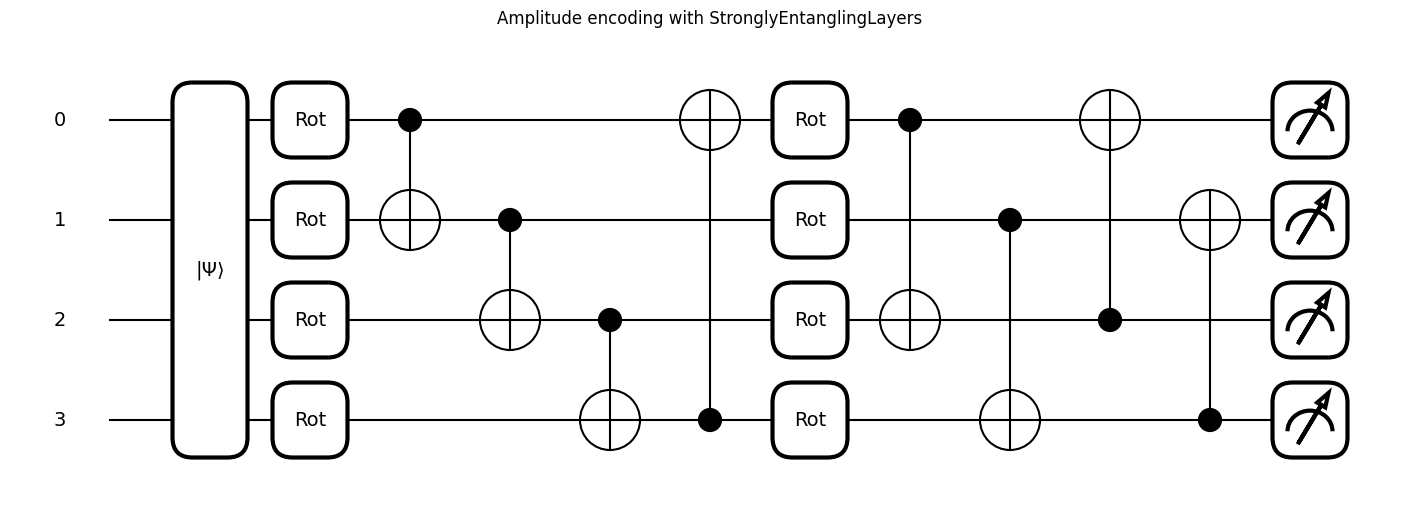

In [11]:
figure, axis = qml.draw_mpl(
    strong_circuit,
    level="device",
)(example_amplitudes)

figure.suptitle(
    "Amplitude encoding with StronglyEntanglingLayers",
    y=1.02,
)
plt.show()

## 12. Architecture experiment


For each design:

1. Prepare the correct amplitude-vector size
2. Run the quantum circuit
3. Measure three values per qubit
4. Train a classical output classifier
5. Calculate validation accuracy

Only validation accuracy is used to select the circuit.

In [12]:
experiment_rows = []
experiment_cache = {}

for template_name in ["Basic", "Strong"]:
    for number_of_qubits in [4, 5, 6]:
        data_for_qubits = prepared_data[number_of_qubits]

        for number_of_layers in [1, 2, 3]:
            circuit, weights = build_quantum_feature_circuit(
                number_of_qubits=number_of_qubits,
                number_of_layers=number_of_layers,
                template_name=template_name,
            )

            quantum_train = create_quantum_features(
                circuit,
                data_for_qubits["train"],
            )

            quantum_validation = create_quantum_features(
                circuit,
                data_for_qubits["validation"],
            )

            quantum_test = create_quantum_features(
                circuit,
                data_for_qubits["test"],
            )

            comparison_classifier = LogisticRegression(
                max_iter=2000,
                random_state=SEED,
            )

            comparison_classifier.fit(
                quantum_train,
                y_train,
            )

            validation_predictions = (
                comparison_classifier.predict(
                    quantum_validation
                )
            )

            validation_accuracy = accuracy_score(
                y_validation,
                validation_predictions,
            )

            if template_name == "Basic":
                number_of_quantum_parameters = (
                    number_of_layers
                    * number_of_qubits
                )
            else:
                number_of_quantum_parameters = (
                    3
                    * number_of_layers
                    * number_of_qubits
                )

            key = (
                template_name,
                number_of_qubits,
                number_of_layers,
            )

            experiment_cache[key] = {
                "circuit": circuit,
                "weights": weights,
                "quantum_train": quantum_train,
                "quantum_validation": quantum_validation,
                "quantum_test": quantum_test,
            }

            experiment_rows.append({
                "Template": template_name,
                "Qubits": number_of_qubits,
                "Layers": number_of_layers,
                "State amplitudes": 2 ** number_of_qubits,
                "Quantum parameters": number_of_quantum_parameters,
                "Measured features": 3 * number_of_qubits,
                "PCA information (%)": (
                    100
                    * data_for_qubits["variance"]
                ),
                "Validation accuracy": validation_accuracy,
            })

results = pd.DataFrame(experiment_rows)

# A validation tie is resolved in favor of the Strong template.
# This lets the final lesson study the richer layer pattern.
results["Template priority"] = results["Template"].map({
    "Strong": 0,
    "Basic": 1,
})

results = results.sort_values(
    by=[
        "Validation accuracy",
        "Template priority",
        "Qubits",
        "Layers",
    ],
    ascending=[False, True, True, True],
).reset_index(drop=True)

results = results.drop(columns=["Template priority"])

results.round(3)

,Template,Qubits,Layers,State amplitudes,Quantum parameters,Measured features,PCA information (%),Validation accuracy
0,Strong,5,3,32,45,15,95.500,0.847
1,Basic,6,1,64,6,18,100.000,0.847
2,Basic,4,2,16,8,12,82.673,0.840
3,Strong,4,1,16,12,12,82.673,0.826
4,Strong,4,3,16,36,12,82.673,0.826
5,Basic,4,1,16,4,12,82.673,0.826
6,Strong,6,1,64,18,18,100.000,0.812
7,Strong,5,2,32,30,15,95.500,0.799
8,Strong,6,3,64,54,18,100.000,0.799
9,Basic,5,1,32,5,15,95.500,0.799


## 13. Compare qubit counts

Each graph shows one template.

Each line represents a different number of layers.

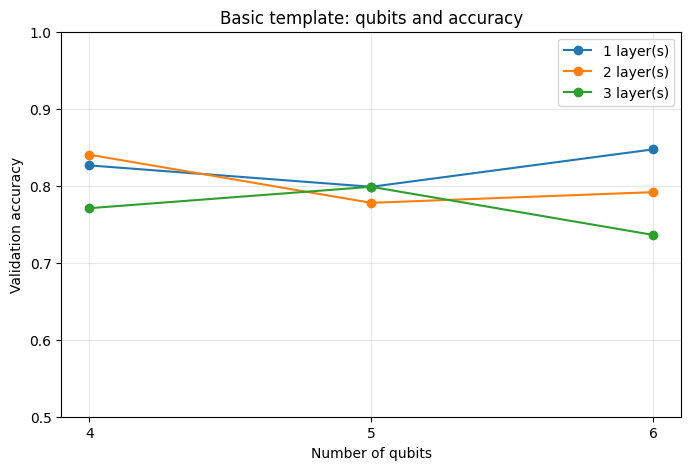

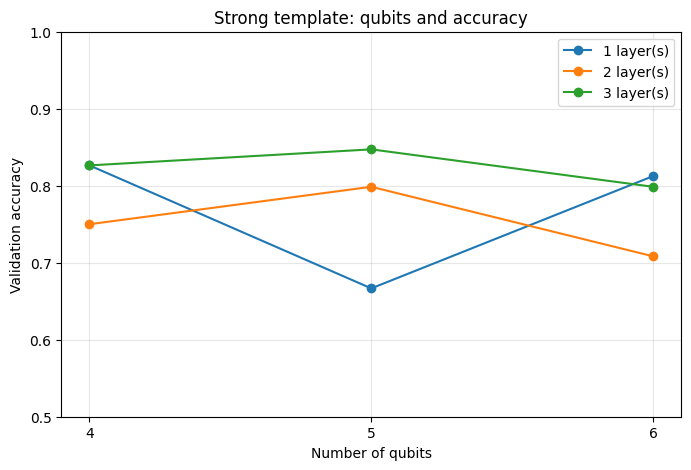

In [13]:
for template_name in ["Basic", "Strong"]:
    template_results = results[
        results["Template"] == template_name
    ]

    plt.figure(figsize=(8, 5))

    for number_of_layers in [1, 2, 3]:
        layer_results = template_results[
            template_results["Layers"]
            == number_of_layers
        ].sort_values("Qubits")

        plt.plot(
            layer_results["Qubits"],
            layer_results["Validation accuracy"],
            marker="o",
            label=f"{number_of_layers} layer(s)",
        )

    plt.xlabel("Number of qubits")
    plt.ylabel("Validation accuracy")
    plt.title(
        f"{template_name} template: qubits and accuracy"
    )
    plt.xticks([4, 5, 6])
    plt.ylim(0.5, 1.0)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 14. Compare layer counts

Each graph shows one template.

Each line represents a different number of qubits.

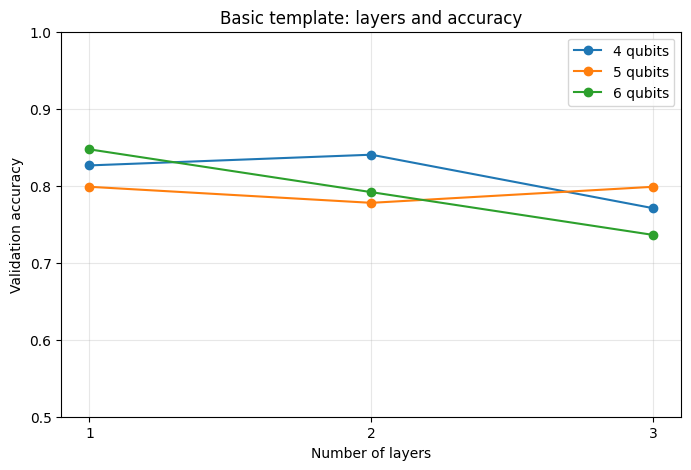

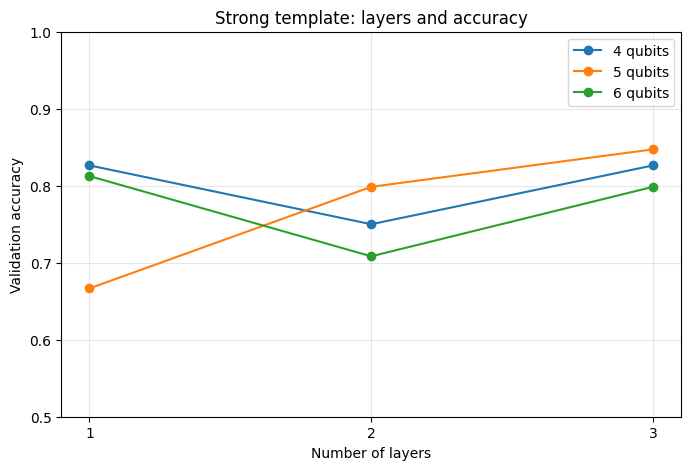

In [14]:
for template_name in ["Basic", "Strong"]:
    template_results = results[
        results["Template"] == template_name
    ]

    plt.figure(figsize=(8, 5))

    for number_of_qubits in [4, 5, 6]:
        qubit_results = template_results[
            template_results["Qubits"]
            == number_of_qubits
        ].sort_values("Layers")

        plt.plot(
            qubit_results["Layers"],
            qubit_results["Validation accuracy"],
            marker="o",
            label=f"{number_of_qubits} qubits",
        )

    plt.xlabel("Number of layers")
    plt.ylabel("Validation accuracy")
    plt.title(
        f"{template_name} template: layers and accuracy"
    )
    plt.xticks([1, 2, 3])
    plt.ylim(0.5, 1.0)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 15. Select the best circuit

The best circuit is the row with the highest validation accuracy.

When two designs have the same validation accuracy, this lesson selects the Strong template so students can examine the richer layer pattern.

The test labels were not used in this selection.

In [15]:
best_result = results.iloc[0]

best_template = str(best_result["Template"])
best_qubits = int(best_result["Qubits"])
best_layers = int(best_result["Layers"])

print("Selected template:", best_template)
print("Selected qubits:", best_qubits)
print("Selected layers:", best_layers)
print(
    "Validation accuracy used for selection:",
    f"{best_result['Validation accuracy'] * 100:.1f}%",
)

Selected template: Strong
Selected qubits: 5
Selected layers: 3
Validation accuracy used for selection: 84.7%


## 16. Train the final output layer

The quantum circuit creates features.

The output classifier learns from those quantum features over many epochs.

We record:

- Training loss
- Training accuracy
- Validation accuracy

In [16]:
best_key = (
    best_template,
    best_qubits,
    best_layers,
)

best_cache = experiment_cache[best_key]

best_quantum_train = best_cache["quantum_train"]
best_quantum_validation = best_cache[
    "quantum_validation"
]
best_quantum_test = best_cache["quantum_test"]

quantum_feature_scaler = StandardScaler()

scaled_quantum_train = (
    quantum_feature_scaler.fit_transform(
        best_quantum_train
    )
)

scaled_quantum_validation = (
    quantum_feature_scaler.transform(
        best_quantum_validation
    )
)

scaled_quantum_test = (
    quantum_feature_scaler.transform(
        best_quantum_test
    )
)

final_classifier = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.02,
    penalty="l2",
    alpha=0.001,
    random_state=SEED,
)

classes = np.array([0, 1, 2, 3])
epochs = 120

loss_history = []
training_accuracy_history = []
validation_accuracy_history = []

random_generator = np.random.default_rng(SEED)

for epoch in range(epochs):
    order = random_generator.permutation(
        len(scaled_quantum_train)
    )

    final_classifier.partial_fit(
        scaled_quantum_train[order],
        y_train[order],
        classes=classes,
    )

    training_probabilities = (
        final_classifier.predict_proba(
            scaled_quantum_train
        )
    )

    epoch_loss = log_loss(
        y_train,
        training_probabilities,
        labels=classes,
    )

    training_predictions = final_classifier.predict(
        scaled_quantum_train
    )

    validation_predictions = (
        final_classifier.predict(
            scaled_quantum_validation
        )
    )

    epoch_training_accuracy = accuracy_score(
        y_train,
        training_predictions,
    )

    epoch_validation_accuracy = accuracy_score(
        y_validation,
        validation_predictions,
    )

    loss_history.append(epoch_loss)
    training_accuracy_history.append(
        epoch_training_accuracy
    )
    validation_accuracy_history.append(
        epoch_validation_accuracy
    )

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Loss: {epoch_loss:.3f} | "
            f"Train accuracy: "
            f"{epoch_training_accuracy:.3f} | "
            f"Validation accuracy: "
            f"{epoch_validation_accuracy:.3f}"
        )

Epoch  20 | Loss: 0.458 | Train accuracy: 0.854 | Validation accuracy: 0.840
Epoch  40 | Loss: 0.455 | Train accuracy: 0.861 | Validation accuracy: 0.840
Epoch  60 | Loss: 0.452 | Train accuracy: 0.863 | Validation accuracy: 0.840
Epoch  80 | Loss: 0.448 | Train accuracy: 0.868 | Validation accuracy: 0.840
Epoch 100 | Loss: 0.452 | Train accuracy: 0.866 | Validation accuracy: 0.833
Epoch 120 | Loss: 0.451 | Train accuracy: 0.863 | Validation accuracy: 0.833


## 17. Plot the loss

A decreasing loss means that the output classifier is improving its probability predictions.

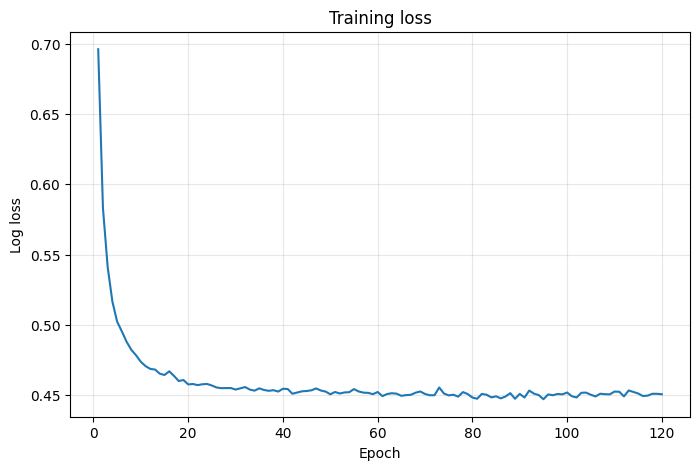

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, epochs + 1),
    loss_history,
)
plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.show()

## 18. Plot training and validation accuracy

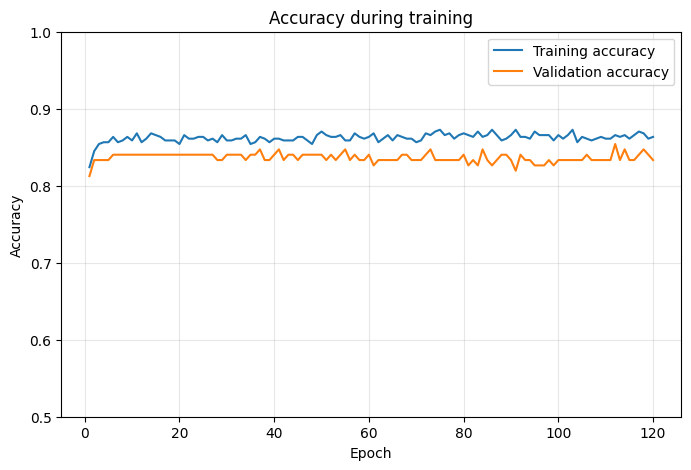

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, epochs + 1),
    training_accuracy_history,
    label="Training accuracy",
)
plt.plot(
    range(1, epochs + 1),
    validation_accuracy_history,
    label="Validation accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.ylim(0.5, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 19. Final test accuracy

We now use the test set for the final evaluation.

In [19]:
final_test_predictions = final_classifier.predict(
    scaled_quantum_test
)

final_test_accuracy = accuracy_score(
    y_test,
    final_test_predictions,
)

print(
    "Final test accuracy:",
    f"{final_test_accuracy * 100:.1f}%",
)

Final test accuracy: 81.2%


## 20. Classification report

The report includes:

- **Precision:** How often a predicted class is correct
- **Recall:** How many examples of a class the model finds
- **F1-score:** A balance between precision and recall
- **Support:** The number of test images in each class

In [20]:
digit_names = [
    "Digit 0",
    "Digit 1",
    "Digit 2",
    "Digit 3",
]

report_text = classification_report(
    y_test,
    final_test_predictions,
    target_names=digit_names,
    digits=3,
)

print(report_text)

              precision    recall  f1-score   support

     Digit 0      0.872     0.944     0.907        36
     Digit 1      0.838     0.861     0.849        36
     Digit 2      0.812     0.743     0.776        35
     Digit 3      0.722     0.703     0.712        37

    accuracy                          0.812       144
   macro avg      0.811     0.813     0.811       144
weighted avg      0.810     0.812     0.811       144



In [21]:
report_dictionary = classification_report(
    y_test,
    final_test_predictions,
    target_names=digit_names,
    output_dict=True,
)

report_table = pd.DataFrame(
    report_dictionary
).transpose()

report_table.round(3)

,precision,recall,f1-score,support
Digit 0,0.872,0.944,0.907,36.000
Digit 1,0.838,0.861,0.849,36.000
Digit 2,0.812,0.743,0.776,35.000
Digit 3,0.722,0.703,0.712,37.000
accuracy,0.812,0.812,0.812,0.812
macro avg,0.811,0.813,0.811,144.000
weighted avg,0.810,0.812,0.811,144.000


## 21. Confusion matrix

Correct predictions appear on the main diagonal.

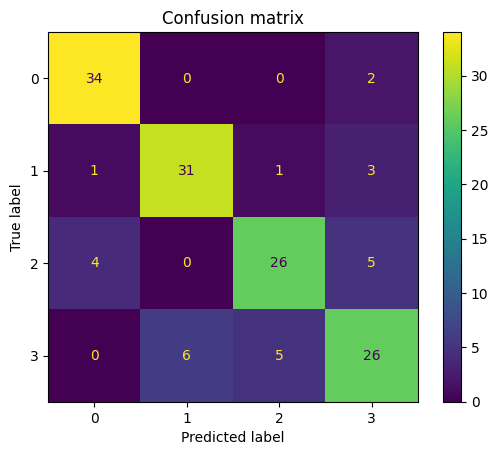

In [22]:
matrix = confusion_matrix(
    y_test,
    final_test_predictions,
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[0, 1, 2, 3],
)

display.plot()
plt.title("Confusion matrix")
plt.show()

## 22. View individual test predictions

The title is green when the prediction is correct and red when it is wrong.

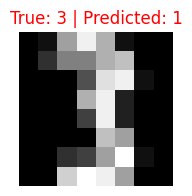

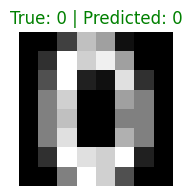

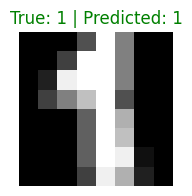

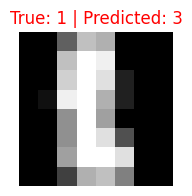

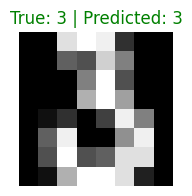

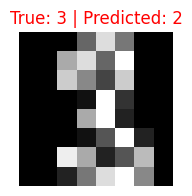

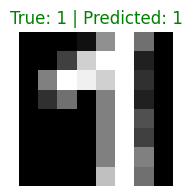

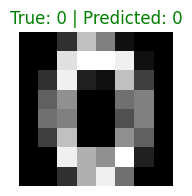

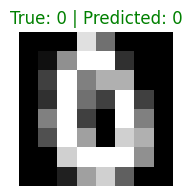

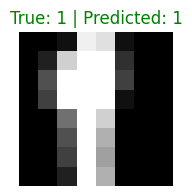

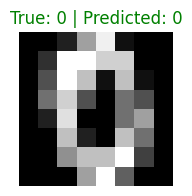

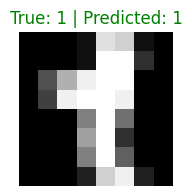

In [23]:
for index in range(12):
    predicted_digit = final_test_predictions[index]
    correct_digit = y_test[index]
    title_color = (
        "green"
        if predicted_digit == correct_digit
        else "red"
    )

    plt.figure(figsize=(2, 2))
    plt.imshow(
        X_test[index].reshape(8, 8),
        cmap="gray",
    )
    plt.title(
        f"True: {correct_digit} | "
        f"Predicted: {predicted_digit}",
        color=title_color,
    )
    plt.axis("off")
    plt.show()

## 23. What did the architecture experiment teach us?

More qubits do not always produce higher accuracy.

More layers do not always produce higher accuracy.

A deeper circuit can create features that are harder for the output classifier to use.

A larger state can preserve more image information, but the circuit and measurements still decide how that information is transformed.

This experiment uses:

- One dataset split
- One random seed
- Fixed random quantum-template weights

Changing any of these choices can change the ranking.

## 24. Student activities

### Activity 1: Increase the classes

Change:

```python
load_digits(n_class=4)
```

to:

```python
load_digits(n_class=5)
```

The model will then classify digits 0 to 4.

### Activity 2: Add more circuit depth

Add `4` to the tested layer values.

Does validation accuracy increase?

### Activity 3: Remove one measurement type

Remove the Pauli-Y measurements.

How many quantum features remain?

### Activity 4: Change the random seed

Change `SEED = 11` to another number.

Does the selected circuit change?

### Activity 5: Use one template only

Run the experiment with only the Basic template or only the Strong template.

Which qubit and layer count is selected?

## Official references

- [PennyLane AmplitudeEmbedding](https://docs.pennylane.ai/en/stable/code/api/pennylane.AmplitudeEmbedding.html)
- [PennyLane BasicEntanglerLayers](https://docs.pennylane.ai/en/stable/code/api/pennylane.BasicEntanglerLayers.html)
- [PennyLane StronglyEntanglingLayers](https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html)
- [scikit-learn Digits dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)
- [scikit-learn classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)